# Mantenimiento Predictivo — AI4I 2020
## Análisis CRISP-DM: Clasificación Binaria

**Dataset:** [AI4I 2020 Predictive Maintenance](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)  
**Objetivo:** Predecir fallas en máquinas industriales (Machine failure: 0/1)  
**Métrica principal:** AUC-ROC + Recall (minimizar fallas no detectadas)  
**Modelos:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, CatBoost


---
## Fase 1 — Comprensión del Negocio

| Aspecto | Detalle |
|---------|---------|
| Objetivo | Predecir fallas antes de que ocurran, reducir downtime |
| Tipo | Clasificación binaria |
| Criterio técnico | AUC-ROC > 0.90, Recall > 0.80 |
| Criterio negocio | Minimizar fallas no detectadas (alto costo de downtime) |
| Restricción | Recall prioritario: falla no detectada >> falsa alarma |
| Usuario final | Equipo de mantenimiento industrial |


---
## Fase 2 — Comprensión de los Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ai4i2020.csv', encoding='utf-8-sig')
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nPrimeras filas:")
print(df.head().to_string())
print(f"\nTipos de datos:")
print(df.dtypes.to_string())


Shape: (10000, 14)
Columnas: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Primeras filas:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF
0    1     M14860    M                298.1                    308.6                    1551         42.8                0                0    0    0    0    0    0
1    2     L47181    L                298.2                    308.7                    1408         46.3                3                0    0    0    0    0    0
2    3     L47182    L                298.1                    308.5                    1498         49.4                5                0    0    0    0    0    0
3    4     L47183    L                298.2                    308.6                    1433        

In [ ]:
df.describe(percentiles=[.05, .25, .5, .75, .95]).round(2)

            UDI  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure       TWF       HDF       PWF       OSF       RNF
count  10000.00              10000.0                 10000.00                10000.00     10000.00         10000.00         10000.00  10000.00  10000.00  10000.00  10000.00  10000.00
mean    5000.50                300.0                   310.01                 1538.78        39.99           107.95             0.03      0.00      0.01      0.01      0.01      0.00
std     2886.90                  2.0                     1.48                  179.28         9.97            63.65             0.18      0.07      0.11      0.10      0.10      0.04
min        1.00                295.3                   305.70                 1168.00         3.80             0.00             0.00      0.00      0.00      0.00      0.00      0.00
5%       500.95                297.1                   307.70                 1332.00

In [ ]:
TARGET = 'Machine failure'
falla_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print(f"Distribución del target '{TARGET}':")
print(df[TARGET].value_counts().to_string())
print(f"\n% Fallas: {df[TARGET].mean()*100:.2f}%")

print(f"\nTipos de falla:")
for col in falla_cols:
    print(f"  {col}: {df[col].sum()} ({df[col].mean()*100:.2f}%)")

print(f"\nTipo de producto:")
print(df['Type'].value_counts().to_string())


Distribución del target 'Machine failure':
Machine failure
0    9661
1     339

% Fallas: 3.39%

Tipos de falla:
  TWF: 46 (0.46%)
  HDF: 115 (1.15%)
  PWF: 95 (0.95%)
  OSF: 98 (0.98%)
  RNF: 19 (0.19%)

Tipo de producto:
Type
L    6000
M    2997
H    1003


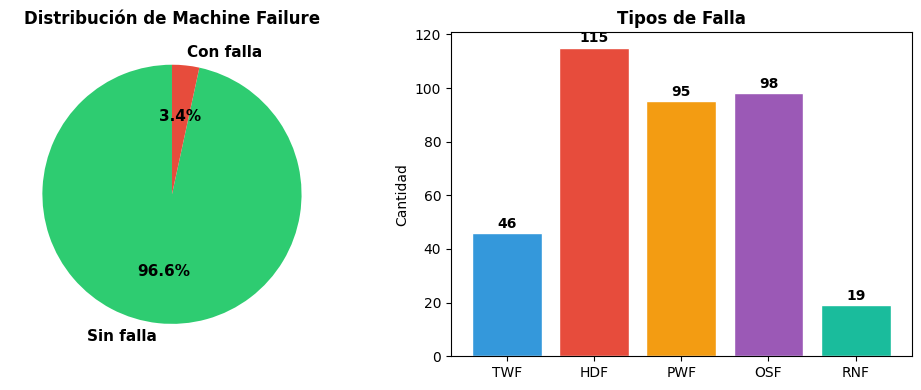

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie([df[TARGET].value_counts()[0], df[TARGET].value_counts()[1]],
            labels=['Sin falla', 'Con falla'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Distribución de Machine Failure', fontsize=12, fontweight='bold')

falla_vals = [df[c].sum() for c in falla_cols]
bars = axes[1].bar(falla_cols, falla_vals,
                   color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'],
                   edgecolor='white')
for bar, val in zip(bars, falla_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Tipos de Falla', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


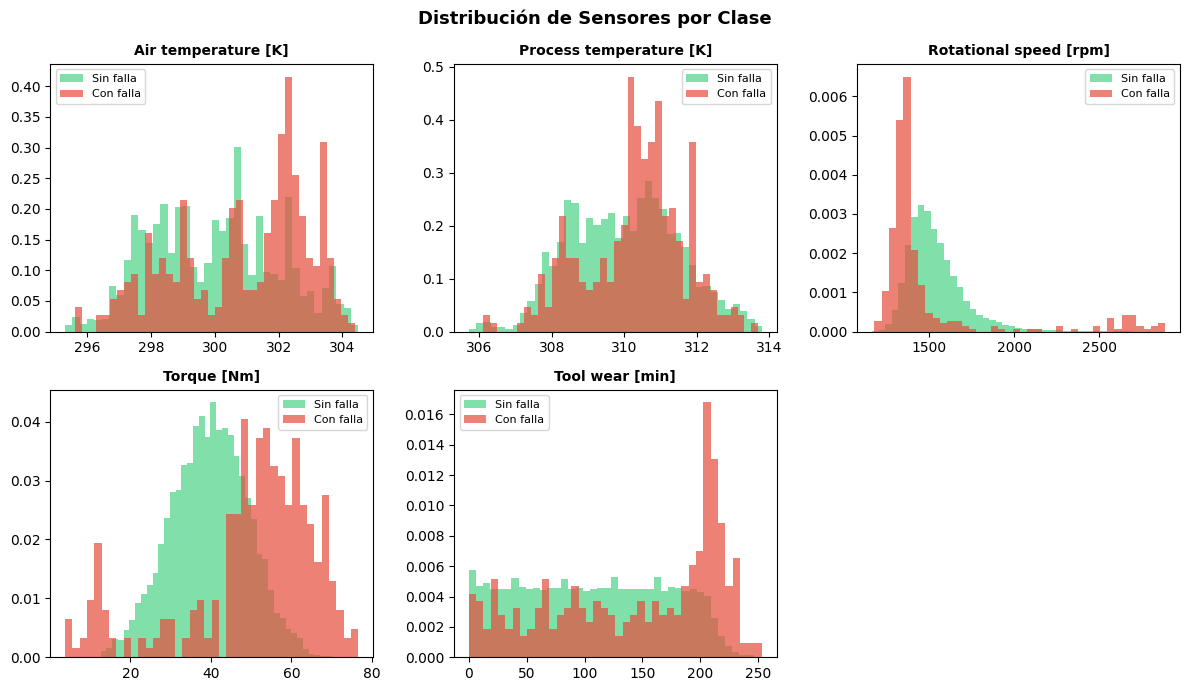

In [ ]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(df[df[TARGET]==0][col], bins=40, alpha=0.6,
                label='Sin falla', color='#2ecc71', density=True)
    axes[i].hist(df[df[TARGET]==1][col], bins=40, alpha=0.7,
                label='Con falla', color='#e74c3c', density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Distribución de Sensores por Clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Correlación con Machine failure:
Machine failure            1.0000
HDF                        0.5758
OSF                        0.5311
PWF                        0.5228
TWF                        0.3629
Torque [Nm]                0.1913
Tool wear [min]            0.1054
Air temperature [K]        0.0826
Process temperature [K]    0.0359
RNF                        0.0045
Rotational speed [rpm]    -0.0442


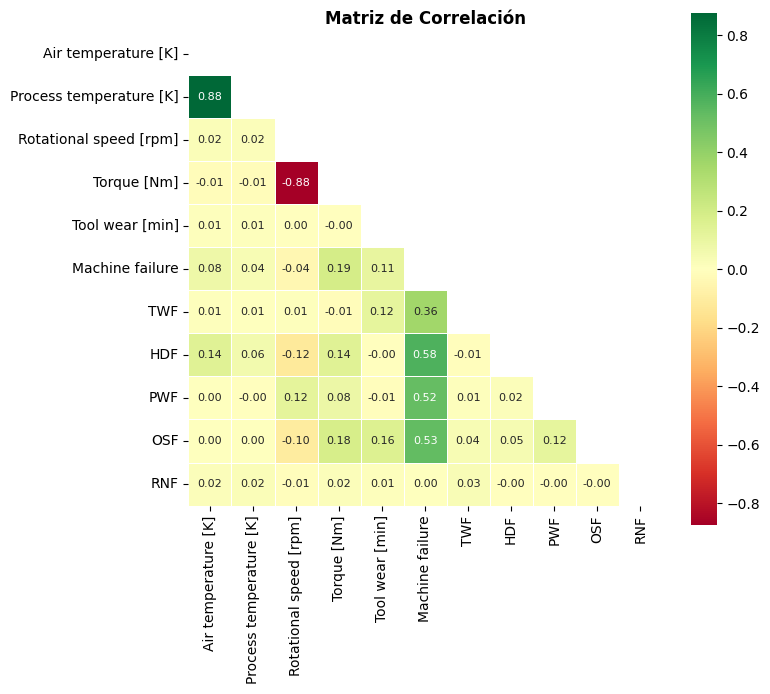

In [ ]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'UDI']

corr_target = df[num_cols].corr()[TARGET].sort_values(ascending=False)
print("Correlación con Machine failure:")
print(corr_target.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(df[num_cols].corr(), dtype=bool))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=ax, mask=mask, square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Insights — Fase 2
- 10,000 registros, 14 columnas, sin valores nulos
- Desbalance severo: solo 3.39% de fallas (339 de 10,000)
- Torque y velocidad rotacional muestran distribuciones más diferenciadas entre clases
- Columnas TWF/HDF/PWF/OSF/RNF son sospechosas de data leakage


---
## Fase 3 — Preparación de Datos

In [ ]:
# Leakage check
df['suma_fallas'] = df[falla_cols].sum(axis=1)
match = ((df['suma_fallas'] > 0) == (df[TARGET] == 1)).mean() * 100
print(f"Coincidencia tipos de falla con target: {match:.1f}%")
print("→ LEAKAGE CONFIRMADO: eliminar columnas de tipo de falla")

# Eliminar leakage + IDs
drop_cols = ['UDI', 'Product ID'] + falla_cols + ['suma_fallas']
df.drop(columns=drop_cols, inplace=True)

# Feature Engineering
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['torque_speed_ratio'] = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1)
df['wear_torque'] = df['Tool wear [min]'] * df['Torque [Nm]']
df['overheat_risk'] = (df['temp_diff'] < 8.6).astype(int)
q05 = df['Rotational speed [rpm]'].quantile(0.05)
q95 = df['Rotational speed [rpm]'].quantile(0.95)
df['extreme_speed'] = ((df['Rotational speed [rpm]'] < q05) | (df['Rotational speed [rpm]'] > q95)).astype(int)

# Encoding
from sklearn.preprocessing import LabelEncoder
df['Type'] = LabelEncoder().fit_transform(df['Type'])

ALL_FEATURES = [c for c in df.columns if c != TARGET]
print(f"\nFeatures creadas: temp_diff, power, torque_speed_ratio, wear_torque, overheat_risk, extreme_speed")
print(f"Shape final: {df.shape}")
print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")


Coincidencia tipos de falla con target: 99.7%
→ LEAKAGE CONFIRMADO: eliminar columnas de tipo de falla

Features creadas: temp_diff, power, torque_speed_ratio, wear_torque, overheat_risk, extreme_speed
Shape final: (10000, 13)
Features (12): ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power', 'torque_speed_ratio', 'wear_torque', 'overheat_risk', 'extreme_speed']


### Insights — Fase 3
- Leakage confirmado: tipos de falla coinciden 99.7% con target → eliminados
- 6 features de ingeniería creadas desde conocimiento de dominio industrial


---
## Fase 4 — Modelado

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, recall_score, precision_score)

X = df[ALL_FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
y_test_arr = np.array(y_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fallas: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test fallas:  {y_test.sum()} ({y_test.mean()*100:.2f}%)")

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                             n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, random_state=42,
                                    auto_class_weights='Balanced', verbose=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probas = {}
resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train_s, y_train)
    y_pred = modelo.predict(X_test_s)
    y_proba = modelo.predict_proba(X_test_s)[:, 1]
    probas[nombre] = y_proba

    auc = roc_auc_score(y_test_arr, y_proba)
    cv_scores = cross_val_score(modelo, X_train_s, y_train, cv=cv, scoring='roc_auc')
    resultados.append({
        'Modelo': nombre,
        'AUC-ROC': round(auc, 4),
        'F1': round(f1_score(y_test_arr, y_pred), 4),
        'Recall': round(recall_score(y_test_arr, y_pred), 4),
        'Precision': round(precision_score(y_test_arr, y_pred), 4),
        'CV_AUC': f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'
    })

df_resultados = pd.DataFrame(resultados).sort_values('AUC-ROC', ascending=False)
print("\nTABLA COMPARATIVA DE MODELOS")
print("=" * 90)
print(df_resultados.to_string(index=False))

mejor = df_resultados.iloc[0]['Modelo']
print(f"\n🏆 Mejor modelo: {mejor}")


Train: (8000, 12) | Test: (2000, 12)
Train fallas: 271 (3.39%)
Test fallas:  68 (3.40%)

TABLA COMPARATIVA DE MODELOS
             Modelo  AUC-ROC     F1  Recall  Precision          CV_AUC
      Random Forest   0.9869 0.8819  0.8235     0.9492 0.9831 ± 0.0096
           CatBoost   0.9730 0.8613  0.8676     0.8551 0.9761 ± 0.0097
  Gradient Boosting   0.9616 0.8800  0.8088     0.9649 0.9746 ± 0.0157
Logistic Regression   0.9527 0.3217  0.8824     0.1967 0.9417 ± 0.0150
      Decision Tree   0.9069 0.5820  0.8088     0.4545 0.9276 ± 0.0171

🏆 Mejor modelo: Random Forest



Classification Report — Random Forest:
              precision    recall  f1-score   support

   Sin falla       0.99      1.00      1.00      1932
   Con falla       0.95      0.82      0.88        68

    accuracy                           0.99      2000
   macro avg       0.97      0.91      0.94      2000
weighted avg       0.99      0.99      0.99      2000


Classification Report — CatBoost:
              precision    recall  f1-score   support

   Sin falla       1.00      0.99      1.00      1932
   Con falla       0.86      0.87      0.86        68

    accuracy                           0.99      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.99      0.99      0.99      2000



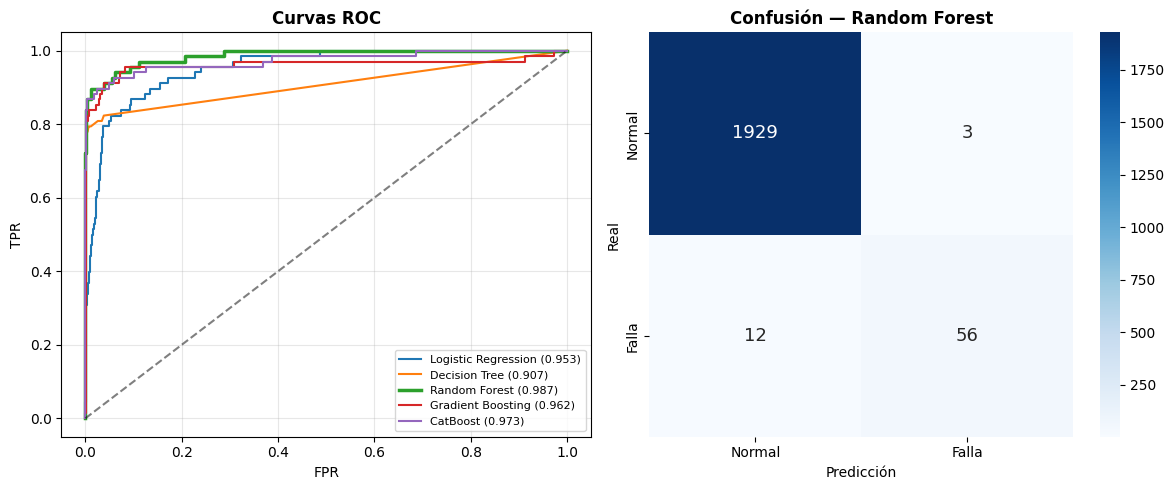

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Curvas ROC — todos los modelos
mejor = 'Random Forest'
for nombre, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test_arr, y_proba)
    auc = roc_auc_score(y_test_arr, y_proba)
    lw = 2.5 if nombre == mejor else 1.5
    axes[0].plot(fpr, tpr, linewidth=lw, label=f'{nombre} ({auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].legend(fontsize=8)
axes[0].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].grid(alpha=0.3)

# Matriz de confusión — Random Forest (mejor AUC)
cm = confusion_matrix(y_test_arr, modelos[mejor].predict(X_test_s))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Falla'],
            yticklabels=['Normal', 'Falla'],
            annot_kws={'size': 13})
axes[1].set_title(f'Confusión — {mejor}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print(f"\nClassification Report — {mejor}:")
print(classification_report(y_test_arr,
      modelos[mejor].predict(X_test_s),
      target_names=['Sin falla', 'Con falla']))

print(f"\nClassification Report — CatBoost:")
print(classification_report(y_test_arr,
      modelos['CatBoost'].predict(X_test_s),
      target_names=['Sin falla', 'Con falla']))


### Insights — Fase 4

| Modelo | AUC-ROC | F1 | Recall | Precision | Observación |
|--------|---------|-----|--------|-----------|-------------|
| **Random Forest** | **0.987** | **0.882** | 0.824 | **0.949** | Mejor AUC, mejor precision |
| CatBoost | 0.973 | 0.861 | **0.868** | 0.855 | **Mejor recall** — detecta más fallas |
| Gradient Boosting | 0.962 | 0.880 | 0.809 | 0.965 | Mayor precision de los 5 |
| Logistic Regression | 0.953 | 0.322 | 0.882 | 0.197 | Alto recall pero muchas falsas alarmas |
| Decision Tree | 0.907 | 0.582 | 0.809 | 0.455 | Menor rendimiento general |

**Análisis RF vs CatBoost:** Random Forest lidera en AUC-ROC (0.987 vs 0.973) y Precision (0.949 vs 0.855), pero CatBoost tiene mejor Recall (0.868 vs 0.824). En un contexto donde una falla no detectada cuesta mucho más que una falsa alarma, CatBoost podría ser preferible. La elección depende del costo relativo de cada tipo de error en la planta específica.


---
## Fase 5 — Evaluación y Refinamiento

Feature Importance — Random Forest:
               Variable  Importancia  Acumulado
     torque_speed_ratio     0.177967  17.796676
        Tool wear [min]     0.140364  31.833035
 Rotational speed [rpm]     0.140154  45.848461
                  power     0.134080  59.256444
            Torque [Nm]     0.133513  72.607755
            wear_torque     0.108169  83.424686
              temp_diff     0.053749  88.799610
          overheat_risk     0.042887  93.088317
    Air temperature [K]     0.028791  95.967398
Process temperature [K]     0.018254  97.792773
          extreme_speed     0.015861  99.378884
                   Type     0.006211 100.000000


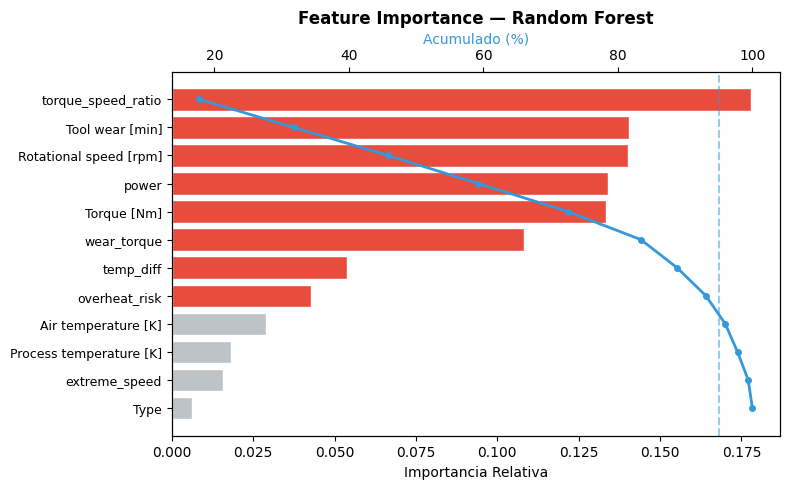

In [ ]:
# Feature Importance — Random Forest (mejor AUC)
rf = modelos['Random Forest']
importancias = rf.feature_importances_
df_imp = pd.DataFrame({
    'Variable': ALL_FEATURES,
    'Importancia': importancias / importancias.sum()
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
df_imp['Acumulado'] = df_imp['Importancia'].cumsum() * 100

print("Feature Importance — Random Forest:")
print(df_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if a <= 95 else '#bdc3c7' for a in df_imp['Acumulado']]
ax.barh(range(len(df_imp)), df_imp['Importancia'], color=colors, edgecolor='white')
ax.set_yticks(range(len(df_imp)))
ax.set_yticklabels(df_imp['Variable'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importancia Relativa', fontsize=10)
ax.set_title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')

ax2 = ax.twiny()
ax2.plot(df_imp['Acumulado'].values, range(len(df_imp)),
         'o-', color='#3498db', linewidth=2, markersize=4)
ax2.axvline(x=95, color='#3498db', linestyle='--', alpha=0.5)
ax2.set_xlabel('Acumulado (%)', fontsize=10, color='#3498db')

plt.tight_layout()
plt.show()


### Insights — Fase 5

**Variables más importantes (Random Forest):**
1. `torque_speed_ratio` (17.8%) — estrés mecánico
2. `Tool wear [min]` (14.0%) — desgaste acumulado
3. `Rotational speed [rpm]` (14.0%) — velocidad del proceso
4. `power` (13.4%) — potencia calculada
5. `Torque [Nm]` (13.4%) — par de torsión

**Decisión:** Mantener modelo completo (12 variables). El modelo reducido degradó Precision en 7.6%.

**RF vs CatBoost — criterio de selección:**
- Si el costo de una falla no detectada >> costo de una falsa alarma → **CatBoost** (Recall 86.8%)
- Si las falsas alarmas también tienen costo operacional significativo → **Random Forest** (Precision 94.9%)
- En la práctica: usar RF como modelo principal y CatBoost como segundo criterio cuando RF predice "no falla" pero la probabilidad está entre 0.3-0.5 (zona de incertidumbre)


---
## Fase 6 — Despliegue

**Modelo seleccionado:** Random Forest (12 variables, class_weight='balanced')

| Métrica | Random Forest | CatBoost |
|---------|--------------|----------|
| AUC-ROC | **0.9869** | 0.9730 |
| F1 | **0.8819** | 0.8613 |
| Recall | 0.8235 | **0.8676** |
| Precision | **0.9492** | 0.8551 |

**Recomendaciones:**
1. Monitorear drift en torque y velocidad rotacional
2. Recalibrar cada 3-6 meses con datos nuevos
3. Umbral de probabilidad ajustable según costo de falsa alarma vs. downtime
4. Considerar CatBoost como modelo complementario para zonas de incertidumbre
5. Integrar con sistema SCADA para alimentación en tiempo real


In [ ]:
import pickle, json

with open('modelo_rf_final.pkl', 'wb') as f:
    pickle.dump(modelos['Random Forest'], f)

with open('modelo_catboost_final.pkl', 'wb') as f:
    pickle.dump(modelos['CatBoost'], f)

metadata = {
    'modelo_principal': 'Random Forest',
    'modelo_complementario': 'CatBoost',
    'features': ALL_FEATURES,
    'target': 'Machine failure',
    'metricas_rf': {'AUC-ROC': 0.9869, 'F1': 0.8819, 'Recall': 0.8235, 'Precision': 0.9492},
    'metricas_catboost': {'AUC-ROC': 0.9730, 'F1': 0.8613, 'Recall': 0.8676, 'Precision': 0.8551},
}
with open('modelo_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modelos guardados: Random Forest + CatBoost")
print(f"Features: {ALL_FEATURES}")


Modelos guardados: Random Forest + CatBoost
Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power', 'torque_speed_ratio', 'wear_torque', 'overheat_risk', 'extreme_speed']
